C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


--- 1. LOGISTIC REGRESSION RESULTS ---
Accuracy Score: 82.12%
Confusion Matrix:
[[92 13]
 [19 55]]


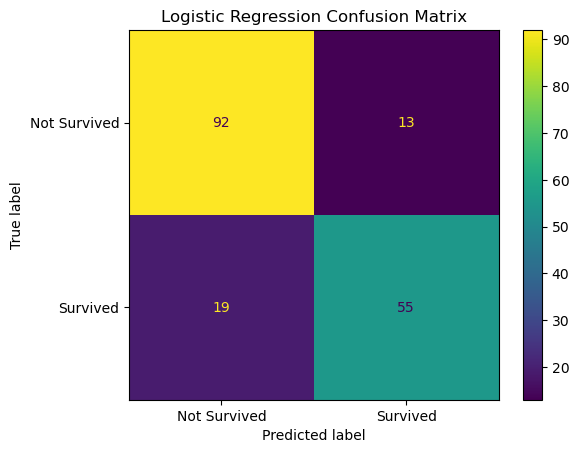


--- 2. MODEL COMPARISON ---
Decision Tree Accuracy: 80.45%
KNN Accuracy: 65.92%

--- 3. TUNING DECISION TREE (max_depth) ---
Decision Tree with max_depth = 2 -> Accuracy: 76.54%
Decision Tree with max_depth = 5 -> Accuracy: 81.56%
Decision Tree with max_depth = 10 -> Accuracy: 81.01%
Decision Tree with max_depth = Unlimited (None) -> Accuracy: 80.45%


In [1]:
# STEP 1: Import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# STEP 2: Load your cleaned Titanic dataset
df_titanic = pd.read_csv('titanic_cleaned_survival.csv')

# STEP 3: Separate features (X) and target variable (y)
# 'Survived' is what we want to predict. The rest are our features.
X = df_titanic.drop(columns=['Survived'])
y = df_titanic['Survived']

# Convert text/categorical columns into numbers (One-Hot Encoding)
X = pd.get_dummies(X, drop_first=True)

# STEP 4: Split data into training set (80%) and testing set (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================================
# Q1 & Assignment 2: Train a Logistic Regression Model
# ==========================================================
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)  # Training the model
y_pred_log = log_reg.predict(X_test)  # Making predictions

# ==========================================================
# Q2: Create Confusion Matrix and Accuracy Score
# ==========================================================
acc_log = accuracy_score(y_test, y_pred_log)
cm_log = confusion_matrix(y_test, y_pred_log)

print("--- 1. LOGISTIC REGRESSION RESULTS ---")
print(f"Accuracy Score: {acc_log * 100:.2f}%")
print("Confusion Matrix:")
print(cm_log)

# Plotting the Confusion Matrix visually
ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=['Not Survived', 'Survived']).plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# ==========================================================
# Q3: Compare DecisionTreeClassifier & KNeighborsClassifier
# ==========================================================
# 1. Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)

# 2. KNN (K-Nearest Neighbors)
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)
acc_knn = accuracy_score(y_test, y_pred_knn)

print("\n--- 2. MODEL COMPARISON ---")
print(f"Decision Tree Accuracy: {acc_dt * 100:.2f}%")
print(f"KNN Accuracy: {acc_knn * 100:.2f}%")

# ==========================================================
# Q4: Tune max_depth of Decision Tree and observe difference
# ==========================================================
print("\n--- 3. TUNING DECISION TREE (max_depth) ---")
for depth in [2, 5, 10, None]:
    tuned_dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tuned_dt.fit(X_train, y_train)
    pred = tuned_dt.predict(X_test)
    acc = accuracy_score(y_test, pred)
    
    depth_label = str(depth) if depth is not None else "Unlimited (None)"
    print(f"Decision Tree with max_depth = {depth_label} -> Accuracy: {acc * 100:.2f}%")